# Final Project: Trust Network Analysis and Fraud Detection in Bitcoin OTC
## Authors: נבו יפלח, ליאל ירדני, אילן קוזוקרו

This document contains the complete code, analysis, and explanations for the Graph Algorithms final project.


In [1]:
# Install dependencies so the notebook runs end-to-end on a clean machine
# (safe to re-run; pip skips anything already satisfied)
%pip install -q networkx pandas matplotlib seaborn scikit-learn



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


### 1. Data Loading
Here we load the Bitcoin network data directly from the Stanford SNAP servers without saving a local file, per the project guidelines. The data represents the Bitcoin OTC network where users rate each other (from -10 to +10).


In [2]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings('ignore')

# Display settings
plt.style.use('ggplot')
sns.set_palette('deep')

url = 'https://snap.stanford.edu/data/soc-sign-bitcoinotc.csv.gz'
print("Loading data directly from the network...")
columns = ['SOURCE', 'TARGET', 'RATING', 'TIME']
df = pd.read_csv(url, compression='gzip', names=columns)
df['TIME'] = pd.to_datetime(df['TIME'], unit='s')
print(f"Total records in dataset: {len(df)}")
display(df.head())


Loading data directly from the network...


Total records in dataset: 35592


,SOURCE,TARGET,RATING,TIME
0,6,2,4,2010-11-08 18:45:11.728359938
1,6,5,2,2010-11-08 18:45:41.533780098
2,1,15,1,2010-11-08 19:05:40.390490055
3,4,3,7,2010-11-08 19:41:17.369750023
4,13,16,8,2010-11-08 22:10:54.447459936


### 2. Creating and Splitting the Trust and Distrust Networks
We will create a directed and weighted graph using the NetworkX library. Then we will split it into two separate networks:
* **Trust Network:** Only positive edges (rating > 0)
* **Distrust Network:** Only negative edges (rating < 0)


In [3]:
# Create directed graph
G = nx.from_pandas_edgelist(df, source='SOURCE', target='TARGET', edge_attr=['RATING', 'TIME'], create_using=nx.DiGraph())

print(f"Total nodes in dataset: {G.number_of_nodes()}")
print(f"Total edges (ratings): {G.number_of_edges()}")

# Split into networks
trust_edges = [(u, v, d) for u, v, d in G.edges(data=True) if d['RATING'] > 0]
distrust_edges = [(u, v, d) for u, v, d in G.edges(data=True) if d['RATING'] < 0]

G_trust = nx.DiGraph()
G_trust.add_edges_from(trust_edges)

G_distrust = nx.DiGraph()
G_distrust.add_edges_from(distrust_edges)

print(f"Edges in Trust Network (positive): {G_trust.number_of_edges()}")
print(f"Edges in Distrust Network (negative): {G_distrust.number_of_edges()}")


Total nodes in dataset: 5881
Total edges (ratings): 35592


Edges in Trust Network (positive): 32029
Edges in Distrust Network (negative): 3563


### 3. Exploratory Data Analysis (EDA) and Visualization
We examine the distribution of ratings in the network and the In-Degree distribution. This analysis helps us understand the network density and the ratio of trusted vs. malicious transactions.


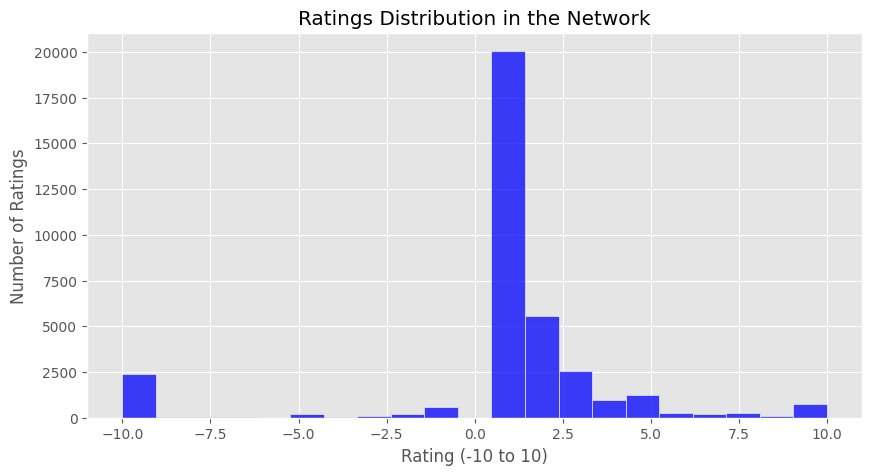

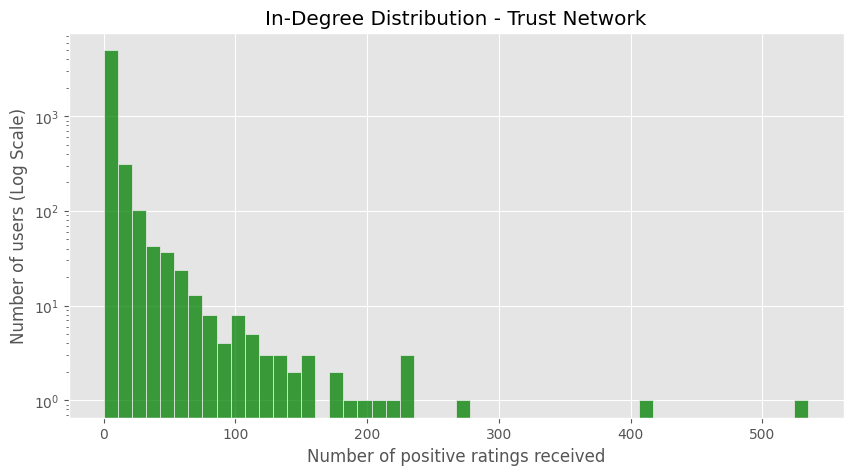

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(df['RATING'], bins=21, kde=False, color='blue')
plt.title('Ratings Distribution in the Network')
plt.xlabel('Rating (-10 to 10)')
plt.ylabel('Number of Ratings')
plt.show()

# In-Degree distribution for Trust Network
in_degrees_trust = [d for n, d in G_trust.in_degree()]
plt.figure(figsize=(10, 5))
sns.histplot(in_degrees_trust, bins=50, kde=False, color='green')
plt.title('In-Degree Distribution - Trust Network')
plt.xlabel('Number of positive ratings received')
plt.ylabel('Number of users (Log Scale)')
plt.yscale('log') # Logarithmic scale for power-law tail
plt.show()


### 4. Centrality Metrics and Key Users
We use PageRank on the Trust Network to find the top users who form the trusted core of the platform. We use weighted In-Degree on the Distrust Network to identify the most prominent scammers who absorbed the most negative ratings.


In [5]:
# PageRank on trust network
pagerank_scores = nx.pagerank(G_trust, weight='RATING')
top_trusted = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:10]
print("--- Top 10 Most Trusted Users (Network Core, by PageRank) ---")
for node, score in top_trusted:
    print(f"User ID: {node:4d} | PageRank Score: {score:.4f}")

# Calculate weighted In-Degree on distrust network
distrust_in_degree = dict(G_distrust.in_degree(weight='RATING'))
# Ratings are negative, so a lower (more negative) value means more distrust
top_distrusted = sorted(distrust_in_degree.items(), key=lambda x: x[1])[:10]
print("\n--- Top 10 Most Untrusted Users / Scammers (by cumulative negative ratings) ---")
for node, score in top_distrusted:
    print(f"User ID: {node:4d} | Total Negative Rating: {score}")


--- Top 10 Most Trusted Users (Network Core, by PageRank) ---
User ID:   35 | PageRank Score: 0.0161
User ID: 2642 | PageRank Score: 0.0135
User ID:    1 | PageRank Score: 0.0091
User ID:    7 | PageRank Score: 0.0088
User ID: 1810 | PageRank Score: 0.0076
User ID: 4172 | PageRank Score: 0.0070
User ID: 2028 | PageRank Score: 0.0069
User ID: 1953 | PageRank Score: 0.0060
User ID: 1018 | PageRank Score: 0.0059
User ID: 2125 | PageRank Score: 0.0053

--- Top 10 Most Untrusted Users / Scammers (by cumulative negative ratings) ---
User ID: 3744 | Total Negative Rating: -725
User ID: 1810 | Total Negative Rating: -385
User ID: 2028 | Total Negative Rating: -342
User ID: 1383 | Total Negative Rating: -338
User ID: 2498 | Total Negative Rating: -296
User ID:  905 | Total Negative Rating: -290
User ID: 2017 | Total Negative Rating: -288
User ID: 3897 | Total Negative Rating: -260
User ID: 4531 | Total Negative Rating: -231
User ID: 4635 | Total Negative Rating: -230


### 5. Community Detection (Louvain) and Identifying Malicious Groups
We use the `Louvain` algorithm to break the Trust Network into dense communities. The goal is to find small communities that rate each other positively, but absorb a high percentage of negative ratings from users outside the community. This situation strongly indicates a Sybil Attack attempting to fake a good reputation.


In [6]:
from networkx.algorithms.community import louvain_communities

# Run Louvain on the undirected version of the trust network.
# seed=42 makes the community partition reproducible (Louvain is randomized).
G_trust_undirected = G_trust.to_undirected()
communities = louvain_communities(G_trust_undirected, weight='RATING', resolution=1.0, seed=42)
print(f"Identified {len(communities)} communities in the Trust Network.")

# Analyze communities
community_sizes = [len(c) for c in communities]
sorted_communities = sorted(communities, key=len, reverse=True)

print("Sizes of the top 5 communities:", [len(c) for c in sorted_communities[:5]])

# Check how many negative ratings each community "absorbed" from outside
community_distrust = []
for idx, comm in enumerate(sorted_communities[:20]): # Scan large communities
    external_negatives = 0
    for node in comm:
        if node in G_distrust:
            for u, v, data in G_distrust.in_edges(node, data=True):
                # Count if the negative rating came from outside the community
                if u not in comm:
                    external_negatives += abs(data['RATING'])
    community_distrust.append((idx, len(comm), external_negatives))

# Sort by the ratio of external distrust relative to community size
community_distrust_sorted = sorted(community_distrust, key=lambda x: x[2]/x[1] if x[1]>0 else 0, reverse=True)

print("\n--- Highly Suspicious Communities (High ratio of external distrust to community size) ---")
for idx, size, neg in community_distrust_sorted[:5]:
    ratio = neg/size if size > 0 else 0
    print(f"Community #{idx}: Size: {size} nodes | Total External Negative Rating: {neg} | Ratio: {ratio:.2f}")


Identified 42 communities in the Trust Network.
Sizes of the top 5 communities: [875, 858, 773, 533, 523]

--- Highly Suspicious Communities (High ratio of external distrust to community size) ---
Community #15: Size: 32 nodes | Total External Negative Rating: 4365 | Ratio: 136.41
Community #12: Size: 64 nodes | Total External Negative Rating: 1772 | Ratio: 27.69
Community #10: Size: 76 nodes | Total External Negative Rating: 1710 | Ratio: 22.50
Community #18: Size: 16 nodes | Total External Negative Rating: 189 | Ratio: 11.81
Community #17: Size: 16 nodes | Total External Negative Rating: 101 | Ratio: 6.31


### 6. Time-based Link Prediction
We use machine learning to predict whether a rating between two users will be positive (trust) or negative (scam). 
* **Chronological Split (Train/Test Split):** We train the model on early years and try to predict the reliability of connections in later years (a realistic evaluation).
* We use structural metrics like Common Neighbors, PageRank, and Degrees as key features reflecting prior social interaction.


Ratings in Training Set (History): 30314
Ratings in Test Set (Future): 5278

Extracting features for the training set...
Extracting features for the test set...

--- Model Results for Future Prediction (Link Prediction) ---
Accuracy: 0.8707

Classification Report:
                  precision    recall  f1-score   support

Distrust (Neg=0)       0.64      0.07      0.13       338
   Trust (Pos=1)       0.87      0.99      0.93      2191

        accuracy                           0.87      2529
       macro avg       0.76      0.53      0.53      2529
    weighted avg       0.84      0.87      0.82      2529



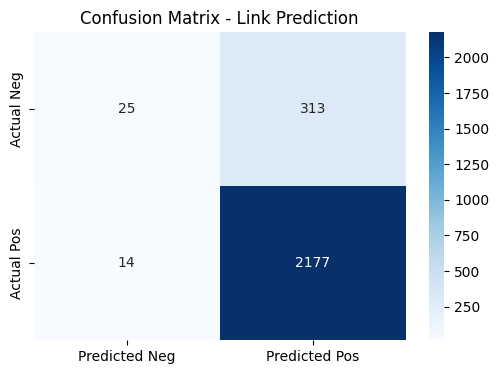

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import datetime

# Chronological split around early 2014
split_date = pd.to_datetime('2014-01-01')
df_train = df[df['TIME'] < split_date].copy()
df_test = df[df['TIME'] >= split_date].copy()

print(f"Ratings in Training Set (History): {len(df_train)}")
print(f"Ratings in Test Set (Future): {len(df_test)}")

# Build training graph (history only) to prevent data leakage
G_train = nx.from_pandas_edgelist(df_train, source='SOURCE', target='TARGET', edge_attr='RATING', create_using=nx.DiGraph())
G_train_undirected = G_train.to_undirected()
pagerank_train = nx.pagerank(G_train)

# Function to extract structural features
def extract_features(data, graph, graph_undir, pr_scores):
    features = []
    labels = []
    
    for row in data.itertuples():
        u = row.SOURCE
        v = row.TARGET
        # Check nodes that existed in the training graph (to use network properties)
        if u in graph and v in graph:
            # Label is 1 (Positive) or 0 (Negative)
            label = 1 if row.RATING > 0 else 0
            
            # Features
            pr_u = pr_scores.get(u, 0)
            pr_v = pr_scores.get(v, 0)
            try:
                common_neighbors = len(list(nx.common_neighbors(graph_undir, u, v)))
            except nx.NetworkXError:
                common_neighbors = 0
            in_deg_v = graph.in_degree(v)
            out_deg_u = graph.out_degree(u)
            
            features.append([pr_u, pr_v, common_neighbors, in_deg_v, out_deg_u])
            labels.append(label)
            
    return np.array(features), np.array(labels)

print("\nExtracting features for the training set...")
X_train, y_train = extract_features(df_train, G_train, G_train_undirected, pagerank_train)
print("Extracting features for the test set...")
X_test, y_test = extract_features(df_test, G_train, G_train_undirected, pagerank_train)

# Build classification model using Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("\n--- Model Results for Future Prediction (Link Prediction) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Distrust (Neg=0)', 'Trust (Pos=1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Neg', 'Predicted Pos'], yticklabels=['Actual Neg', 'Actual Pos'])
plt.title("Confusion Matrix - Link Prediction")
plt.show()


### 7. Threshold Analysis: Is the Fraud Signal Really Missing?
A fraud recall of ~0.07 is easy to misread as "the model learned nothing about fraud." It did not.

`clf.predict()` assigns a class by taking the argmax of the predicted probabilities — effectively a fixed 0.5 cut-off. With ~87% of the test edges positive, almost no pair ever clears that bar for the fraud class. Note that `class_weight='balanced'` reweights the split criterion *inside* each tree, but it does **not** move that 0.5 cut.

To separate the quality of the model from the arbitrariness of the threshold, we evaluate how well the model *ranks* fraud (Average Precision and ROC-AUC, both threshold-free) and then sweep the threshold to expose the precision/recall trade-off available to a real platform.

--- Threshold-free ranking quality (fraud class) ---
Fraud base rate (= AP of a random ranker): 0.1336
Average Precision (AP):                    0.3000  (2.24x baseline)
ROC-AUC:                                   0.6975

--- Threshold sweep ---
  thresh  precision   recall      F1  flagged  caught
    0.50      0.641    0.074   0.133       39      25
    0.40      0.500    0.112   0.184       76      38
    0.30      0.413    0.175   0.245      143      59
    0.25      0.368    0.228   0.282      209      77
    0.20      0.342    0.275   0.305      272      93
    0.15      0.295    0.346   0.319      396     117
    0.10      0.260    0.456   0.331      592     154

Best-F1 operating point: threshold=0.110 precision=0.277 recall=0.435 F1=0.339


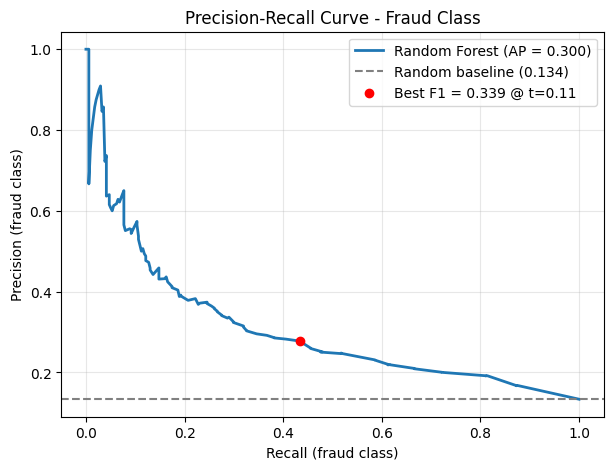

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score

# Column 0 of predict_proba corresponds to class 0 (fraud).
proba_fraud = clf.predict_proba(X_test)[:, 0]
y_fraud = (y_test == 0).astype(int)
base_rate = y_fraud.mean()   # AP of a random ranker equals the positive rate

ap = average_precision_score(y_fraud, proba_fraud)
auc = roc_auc_score(y_fraud, proba_fraud)

print("--- Threshold-free ranking quality (fraud class) ---")
print(f"Fraud base rate (= AP of a random ranker): {base_rate:.4f}")
print(f"Average Precision (AP):                    {ap:.4f}  ({ap/base_rate:.2f}x baseline)")
print(f"ROC-AUC:                                   {auc:.4f}")

# Sweep the decision threshold to expose the precision/recall trade-off.
print("\n--- Threshold sweep ---")
print(f"{'thresh':>8}{'precision':>11}{'recall':>9}{'F1':>8}{'flagged':>9}{'caught':>8}")
for t in [0.5, 0.4, 0.3, 0.25, 0.2, 0.15, 0.1]:
    pred = proba_fraud >= t
    tp = int((pred & (y_fraud == 1)).sum())
    fp = int((pred & (y_fraud == 0)).sum())
    fn = int((~pred & (y_fraud == 1)).sum())
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    print(f"{t:>8.2f}{prec:>11.3f}{rec:>9.3f}{f1:>8.3f}{tp+fp:>9}{tp:>8}")

# Best achievable F1 on the fraud class, and the PR curve behind it.
prec_c, rec_c, thr_c = precision_recall_curve(y_fraud, proba_fraud)
f1_c = np.divide(2 * prec_c * rec_c, prec_c + rec_c,
                 out=np.zeros_like(prec_c), where=(prec_c + rec_c) > 0)
best = int(np.argmax(f1_c))
print(f"\nBest-F1 operating point: threshold={thr_c[best]:.3f} "
      f"precision={prec_c[best]:.3f} recall={rec_c[best]:.3f} F1={f1_c[best]:.3f}")

plt.figure(figsize=(7, 5))
plt.plot(rec_c, prec_c, lw=2, label=f'Random Forest (AP = {ap:.3f})')
plt.axhline(base_rate, ls='--', c='grey', label=f'Random baseline ({base_rate:.3f})')
plt.scatter([rec_c[best]], [prec_c[best]], c='red', zorder=5,
            label=f'Best F1 = {f1_c[best]:.3f} @ t={thr_c[best]:.2f}')
plt.xlabel('Recall (fraud class)')
plt.ylabel('Precision (fraud class)')
plt.title('Precision-Recall Curve - Fraud Class')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Summary and Conclusions
In the model we ran, we can see that topological metrics provide a powerful tool for analyzing user trustworthiness in Bitcoin, even without identifying information.
1. We found that fake / "scammer" groups can be flagged using community detection (Louvain): the analysis revealed small communities that absorb a disproportionate amount of negative ratings from the network's main core — e.g., a 32-node community with an external-distrust ratio of ~136.
2. Using a realistic chronological split, the Link Prediction model reached **87% overall accuracy** and is **excellent at confirming trustworthy links** (positive-class F1 = 0.93). At the default 0.5 decision threshold its recall on the fraud class is only ~0.07, which at first reading looks like a model that learned nothing about fraud.
3. **The threshold analysis shows that reading is wrong.** The model ranks fraud at **AP = 0.30 against a 0.134 random baseline (2.2x)**, with ROC-AUC = 0.70 — the structural features do carry a real fraud signal. What fails is the fixed 0.5 cut-off, not the model: lowering the threshold to ~0.11 raises fraud recall from 0.07 to **0.43** and fraud F1 from 0.13 to **0.34**. The honest way to report this model is therefore as a *ranking* with a tunable operating point, where a platform picks the threshold according to the relative cost of a missed scam versus a false accusation.
4. The remaining headroom is in the **features**, not the threshold: an AP of 0.30 still leaves most fraud far down the ranking. Resampling (SMOTE), explicit Structural-Balance features (counts of balanced/unbalanced triads), or a GNN over the signed graph are the natural next steps.
